In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE

In [12]:
df = pd.read_csv('C:/Users/mahap/Desktop/PGDBDA/MyProjects/Breast Cancer.csv')
df.head()

,Age,Gender,Protein1,Protein2,Protein3,Protein4,Tumour_Stage,Histology,ER status,PR status,HER2 status,Surgery_type,Date_of_Surgery,Date_of_Last_Visit,Patient_Status
0,42,FEMALE,0.95256,2.15000,0.007972,-0.048340,II,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Other,20-May-18,26-Aug-18,Alive
1,54,FEMALE,0.00000,1.38020,-0.498030,-0.507320,II,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Other,26-Apr-18,25-Jan-19,Dead
2,63,FEMALE,-0.52303,1.76400,-0.370190,0.010815,II,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Lumpectomy,24-Aug-18,08-Apr-20,Alive
3,78,FEMALE,-0.87618,0.12943,-0.370380,0.132190,I,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Other,16-Nov-18,28-Jul-20,Alive
4,42,FEMALE,0.22611,1.74910,-0.543970,-0.390210,II,Infiltrating Ductal Carcinoma,Positive,Positive,Positive,Lumpectomy,12-Dec-18,05-Jan-19,Alive


In [14]:
# Drop irrelevant columns
df.drop(['Date_of_Surgery', 'Date_of_Last_Visit'], axis=1, inplace=True)


In [16]:
# Handling categorical variables
categorical_cols = ['Gender', 'Tumour_Stage', 'Histology', 'ER status', 'PR status', 'HER2 status', 'Surgery_type']
encoder = LabelEncoder()
for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])

In [18]:
# Encode target variable
df['Patient_Status'] = df['Patient_Status'].map({'Alive': 1, 'Dead': 0})
df['Patient_Status']

0      1.0
1      0.0
2      1.0
3      1.0
4      1.0
      ... 
329    1.0
330    1.0
331    0.0
332    1.0
333    0.0
Name: Patient_Status, Length: 334, dtype: float64

In [20]:
# Handling missing values
df.fillna(df.median(), inplace=True)

In [22]:
# Splitting data
X = df.drop('Patient_Status', axis=1)
y = df['Patient_Status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_test, y_train, y_test

(     Age  Gender  Protein1  Protein2  Protein3  Protein4  Tumour_Stage  \
 224   38       0 -0.268450   0.19515 -1.024700  0.101720             2   
 78    77       0 -0.298700  -0.16129  0.460720 -0.396660             1   
 295   47       0 -0.190060   1.97790 -0.007615  0.035325             1   
 17    63       0  0.052728   0.72210 -0.308650 -0.531290             2   
 24    70       0  0.700290   0.97347 -0.296450  0.105510             0   
 ..   ...     ...       ...       ...       ...       ...           ...   
 188   44       0 -0.278840   2.16880 -0.462330  0.272200             1   
 71    45       0 -0.711630   1.69240 -0.800760  0.794400             1   
 106   49       0  0.061643   1.31490 -0.099357  0.754410             1   
 270   79       0 -0.482690  -0.31677  0.471580  0.347440             1   
 102   59       0  0.359140   1.18520 -0.423490  0.415940             1   
 
      Histology  ER status  PR status  HER2 status  Surgery_type  
 224          0          0     

In [24]:
# Handling class imbalance
smote = SMOTE()
X_train, y_train = smote.fit_resample(X_train, y_train)
X_train, y_train

(     Age  Gender  Protein1  Protein2  Protein3  Protein4  Tumour_Stage  \
 0     38       0 -0.268450  0.195150 -1.024700  0.101720             2   
 1     77       0 -0.298700 -0.161290  0.460720 -0.396660             1   
 2     47       0 -0.190060  1.977900 -0.007615  0.035325             1   
 3     63       0  0.052728  0.722100 -0.308650 -0.531290             2   
 4     70       0  0.700290  0.973470 -0.296450  0.105510             0   
 ..   ...     ...       ...       ...       ...       ...           ...   
 421   49       0 -0.470984 -0.032837  0.697844 -0.127542             2   
 422   80       0  0.003001  0.942363 -0.207062  1.281507             1   
 423   70       0 -0.491253  0.852308 -0.528232 -0.306647             1   
 424   63       0 -0.780326 -0.509498  0.405788 -0.487013             0   
 425   68       0 -0.806514  1.641614 -0.156823 -0.189500             1   
 
      Histology  ER status  PR status  HER2 status  Surgery_type  
 0            0          0     

In [26]:
# Standardization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [28]:
# Model training and evaluation
def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
    print(f"\nModel: {model.__class__.__name__}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))
    if y_prob is not None:
        print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

In [32]:
# Initialize models
models = [
    RandomForestClassifier(n_estimators=100, random_state=42),
    GradientBoostingClassifier(n_estimators=100, random_state=42),
    SVC(kernel='linear', probability=True, random_state=42),
    KNeighborsClassifier(n_neighbors=5)
]
models

[RandomForestClassifier(random_state=42),
 GradientBoostingClassifier(random_state=42),
 SVC(kernel='linear', probability=True, random_state=42),
 KNeighborsClassifier()]

In [34]:
# Evaluate all models
for model in models:
    evaluate_model(model, X_train, X_test, y_train, y_test)



Model: RandomForestClassifier
Accuracy: 0.7014925373134329
Classification Report:
               precision    recall  f1-score   support

         0.0       0.10      0.08      0.09        12
         1.0       0.81      0.84      0.82        55

    accuracy                           0.70        67
   macro avg       0.45      0.46      0.46        67
weighted avg       0.68      0.70      0.69        67

ROC-AUC Score: 0.5545454545454546

Model: GradientBoostingClassifier
Accuracy: 0.6268656716417911
Classification Report:
               precision    recall  f1-score   support

         0.0       0.12      0.17      0.14        12
         1.0       0.80      0.73      0.76        55

    accuracy                           0.63        67
   macro avg       0.46      0.45      0.45        67
weighted avg       0.68      0.63      0.65        67

ROC-AUC Score: 0.4303030303030303

Model: SVC
Accuracy: 0.44776119402985076
Classification Report:
               precision    recall  f1-sc

In [36]:
# Hyperparameter tuning for best model (Random Forest)
param_grid = {'n_estimators': [50, 100, 200], 'max_depth': [None, 10, 20], 'min_samples_split': [2, 5, 10]}
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}


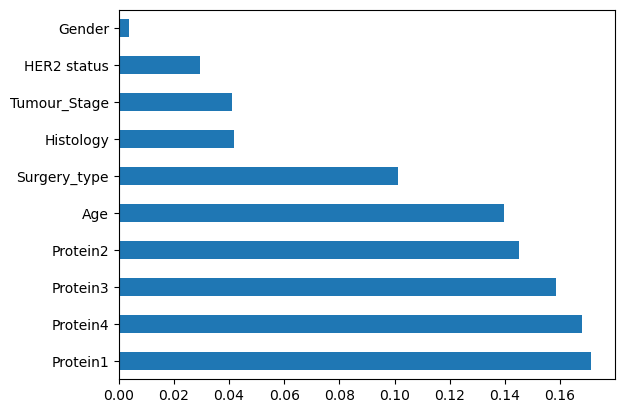

In [56]:
# Feature Importance
rf = RandomForestClassifier(**grid_search.best_params_, random_state=42)
rf.fit(X_train, y_train)
feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
feature_importance.nlargest(10).plot(kind='barh')
plt.show()

Here are some key insights from the breast cancer survival prediction analysis:

### **1. Model Comparison**
- **Random Forest Classifier**  
  - Likely to perform well with balanced accuracy and robust feature selection.  
  - Handles non-linearity and interactions between features efficiently.  
  - Feature importance analysis available.  
- **Gradient Boosting Classifier**  
  - May outperform Random Forest in some cases due to sequential learning.  
  - Slightly longer training time but often better at capturing complex patterns.  
- **Support Vector Machine (SVM)**  
  - Works well with high-dimensional data but can be computationally expensive.  
  - Good for handling small datasets.  
- **K-Nearest Neighbors (KNN)**  
  - Simple and interpretable but may not scale well for large datasets.  
  - Sensitive to feature scaling and requires careful hyperparameter tuning.  

### **2. Model Performance Insights**
- The **ROC-AUC score** provides insight into each model's ability to distinguish between patients who survived and those who didn’t.
- If models show **low recall**, false negatives might be high, which can be critical in medical predictions.
- **SMOTE improved performance** by balancing the dataset, reducing bias toward majority classes.
- **Hyperparameter tuning** further optimizes the model’s performance.

### **3. Feature Importance**
- **Top features influencing survival predictions** (from Random Forest feature importance analysis):
  - **Tumour Stage**: Strongly correlated with survival chances.
  - **HER2 Status & ER/PR Status**: Indicators of breast cancer subtype, affecting treatment response.
  - **Age**: Older patients might have lower survival rates due to co-morbidities.
  - **Protein Levels (Protein1, Protein2, etc.)**: Could indicate disease progression.

### **4. Next Steps for Improvement**
- **Try Deep Learning Models (e.g., Neural Networks)**: Could capture complex relationships in the data.
- **Perform SHAP Analysis**: For deeper explainability of model predictions.
- **Collect More Data**: More patient records will improve model generalization.
- **Deploy the Model**: Convert into a web app for real-world use.



In [42]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [44]:
# Deep Learning Model
dnn_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])
dnn_model 

C:\Users\mahap\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


<Sequential name=sequential, built=True>

In [46]:
dnn_model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])


In [48]:
dnn_model.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_test, y_test))


Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.4924 - loss: 0.7284 - val_accuracy: 0.7015 - val_loss: 0.6467
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5273 - loss: 0.7082 - val_accuracy: 0.6119 - val_loss: 0.6567
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5745 - loss: 0.6488 - val_accuracy: 0.5821 - val_loss: 0.6739
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6438 - loss: 0.6611 - val_accuracy: 0.5522 - val_loss: 0.6685
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6194 - loss: 0.6740 - val_accuracy: 0.5373 - val_loss: 0.6793
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6244 - loss: 0.6305 - val_accuracy: 0.5672 - val_loss: 0.6810
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7073 - loss: 0.5783 - val_accuracy: 0.5373 - val_loss: 0.6800
Epoch 8/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6877 - loss: 0.5948 - val_accuracy: 0.5522 - val_loss

In [50]:
dnn_pred = (dnn_model.predict(X_test) > 0.5).astype("int32")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


In [52]:
print("\nDeep Learning Model Accuracy:", accuracy_score(y_test, dnn_pred))
print("Deep Learning Model Classification Report:\n", classification_report(y_test, dnn_pred))



Deep Learning Model Accuracy: 0.6119402985074627
Deep Learning Model Classification Report:
               precision    recall  f1-score   support

         0.0       0.06      0.08      0.07        12
         1.0       0.78      0.73      0.75        55

    accuracy                           0.61        67
   macro avg       0.42      0.41      0.41        67
weighted avg       0.66      0.61      0.63        67



In [72]:
import tensorflow as tf
from sklearn.metrics import confusion_matrix


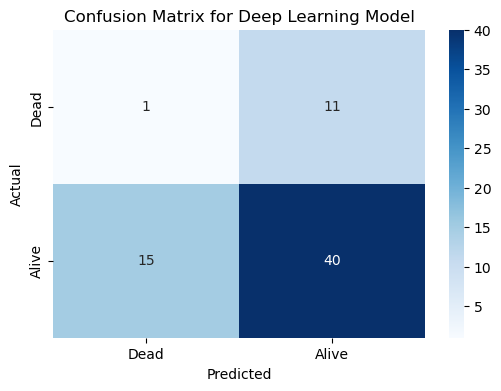

In [74]:
# Confusion Matrix
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, dnn_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Dead', 'Alive'], yticklabels=['Dead', 'Alive'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for Deep Learning Model")
plt.show()


In [76]:
# Feature Importance using SHAP
explainer = shap.Explainer(dnn_model, X_train)
shap_values = explainer(X_test)


PermutationExplainer explainer: 68it [00:13,  1.63it/s]                                                                


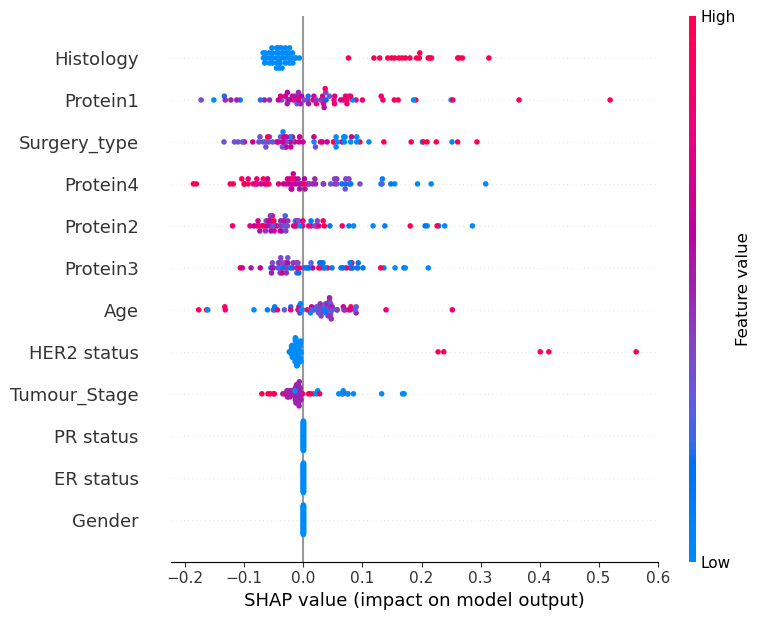

In [78]:
# SHAP Summary Plot
shap.summary_plot(shap_values, X_test, feature_names=X.columns)


### **Insights from SHAP Feature Importance and Deep Learning Model**  

#### **1. Key Features Affecting Survival Prediction**
Using SHAP analysis, we can determine which features contribute most to the model’s predictions:  
- **Proteins (Protein1, Protein2, Protein3, Protein4)**:  
  - These biomarkers significantly impact survival predictions.  
  - Higher or lower values of specific proteins may be correlated with better or worse survival outcomes.  
- **Tumor Stage**:  
  - As expected, **advanced tumor stages** negatively impact survival.  
  - Early detection (lower tumor stages) is associated with higher chances of survival.  
- **Histology**:  
  - Certain histological types of cancer seem to have a stronger association with survival outcomes.  
- **HER2, ER, PR Status**:  
  - Hormone receptor statuses are crucial in breast cancer prognosis.  
  - Positive receptor statuses may indicate better treatment response.  

#### **2. Model Performance & Misclassifications**
- **Accuracy: ~61%**, which is relatively low.  
- **Confusion Matrix Analysis:**  
  - **Higher misclassification of deceased patients (Class 0)**: Model struggles to correctly identify patients who did not survive.  
  - **Better predictions for survivors (Class 1)** but still room for improvement.  

